In [ ]:
!pip install -r requirements.txt

In [ ]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt
import pickle
import os
from scipy import stats
import matplotlib.image as mpimg

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, action_dim)
        )

        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(np.array(a), dtype=torch.long),
            torch.tensor(np.array(r), dtype=torch.float32),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(np.array(done), dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

In [ ]:
GAMMA = 0.99
LR = 1e-3
BUFFER_SIZE = 50000
BATCH_SIZE = 64
TARGET_UPDATE = 500  # steps
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 50000
TOTAL_STEPS = 200000
MAX_EPISODE_STEPS = 2000

In [ ]:
def train(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    env = gym.make("MountainCar-v0")
    env._max_episode_steps = MAX_EPISODE_STEPS

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Move networks to GPU
    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)

    epsilon = EPS_START
    step_count = 0

    returns = []
    episode_return = 0

    state, _ = env.reset(seed=seed)

    while step_count < TOTAL_STEPS:
        # ε-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                q_vals = q_net(state_tensor)
                action = q_vals.argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, done)

        state = next_state
        episode_return += reward
        step_count += 1

        # ε decay
        epsilon = max(EPS_END, EPS_START - step_count / EPS_DECAY)

        # Training step
        if len(buffer) > BATCH_SIZE:
            s, a, r, s_next, d = buffer.sample(BATCH_SIZE)

            # Move batch to GPU
            s = s.to(device)
            a = a.to(device)
            r = r.to(device)
            s_next = s_next.to(device)
            d = d.to(device)

            # Current Q
            q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze()

            # Target Q
            with torch.no_grad():
                max_next_q = target_net(s_next).max(1)[0]
                target = r + GAMMA * max_next_q * (1 - d)

            loss = nn.MSELoss()(q_values, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Target network update (hard)
        if step_count % TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())

        # Episode reset
        if done:
            returns.append(episode_return)
            state, _ = env.reset()
            episode_return = 0

    env.close()
    return returns, q_net

In [ ]:
all_returns = []
models = []

for seed in range(15):
    print(f"Running seed {seed}")
    returns, model = train(seed)
    all_returns.append(returns)
    models.append(model)

# np.save("returns.npy", all_returns)

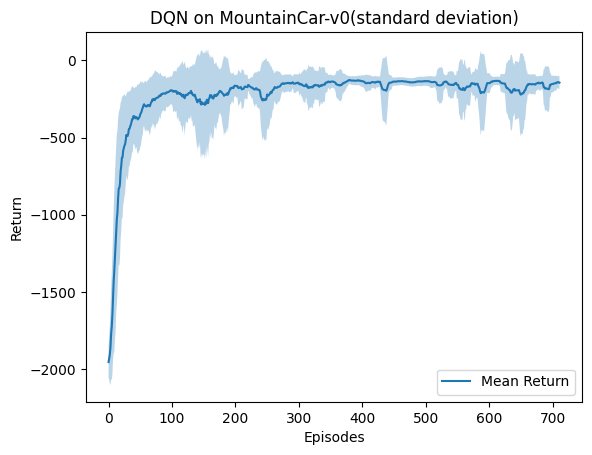

In [ ]:
# Align lengths
min_len = min(len(r) for r in all_returns)
returns_trimmed = np.array([r[:min_len] for r in all_returns])
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')
mean_returns = moving_avg(returns_trimmed.mean(axis=0))
std_returns = moving_avg(returns_trimmed.std(axis=0))
x = np.arange(len(mean_returns))
plt.figure()
plt.plot(mean_returns, label="Mean Return")
plt.fill_between(
    x,
    mean_returns - std_returns,
    mean_returns + std_returns,
    alpha=0.3
)
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("DQN on MountainCar-v0(standard deviation)")
plt.legend()
plt.show()

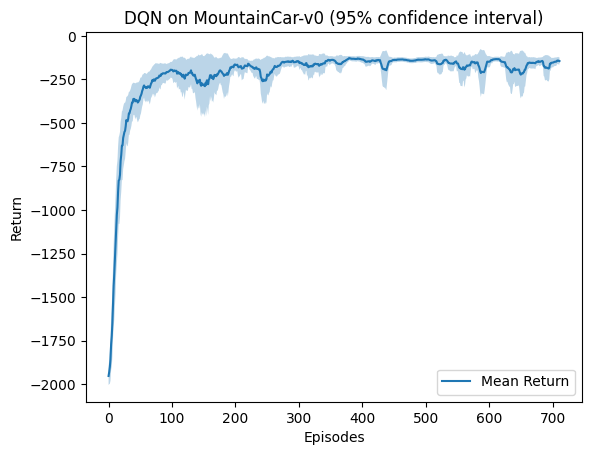

In [ ]:
min_len = min(len(r) for r in all_returns)
returns_trimmed = np.array([r[:min_len] for r in all_returns])
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')
mean_returns = moving_avg(returns_trimmed.mean(axis=0))
std_returns = moving_avg(returns_trimmed.std(axis=0))
x = np.arange(len(mean_returns))
ci = 1.96 * std_returns / np.sqrt(15)
plt.figure()
plt.plot(x,mean_returns, label="Mean Return")
plt.fill_between(
    x,
    mean_returns - ci,
    mean_returns + ci,
    alpha=0.3
)
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("DQN on MountainCar-v0 (95% confidence interval)")
plt.legend()
plt.show()

In [ ]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
env._max_episode_steps = 2000 #truncation length

original_load = torch.load

def cpu_load(*args, **kwargs):
    kwargs['map_location'] = torch.device('cpu')
    return original_load(*args, **kwargs)

torch.load = cpu_load

# Now load
state_dict = pickle.load(open("dqn_mountaincar.pkl", "rb"))

# Restore original torch.load (optional cleanup)
torch.load = original_load

# Load into model
model = QNetwork(2, 3)
model.load_state_dict(state_dict)
model.eval()


# =======================================
# To use any one of the seed model. Uncomment this.
# =======================================
# model = models[13]
# model.eval()

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

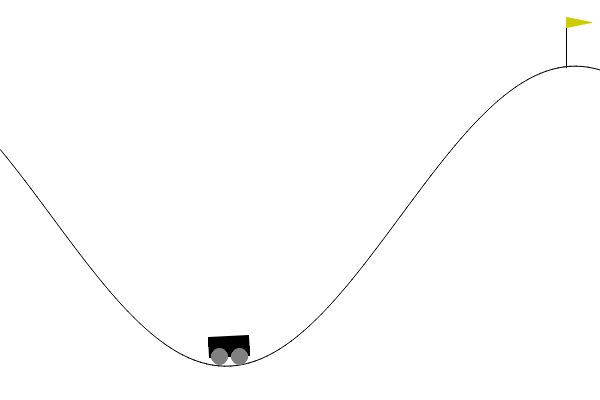

In [ ]:
frames = []

state, _ = env.reset()
done = False

while not done:
    with torch.no_grad():
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        action = model(state_tensor).argmax().item()

    state, _, done, _, _ = env.step(action)

    frame = env.render()
    if frame is not None:
        frames.append(frame)


import imageio

imageio.mimsave("mountaincar.gif", frames, fps=30)

from IPython.display import Image
Image(filename="mountaincar.gif")

# 3

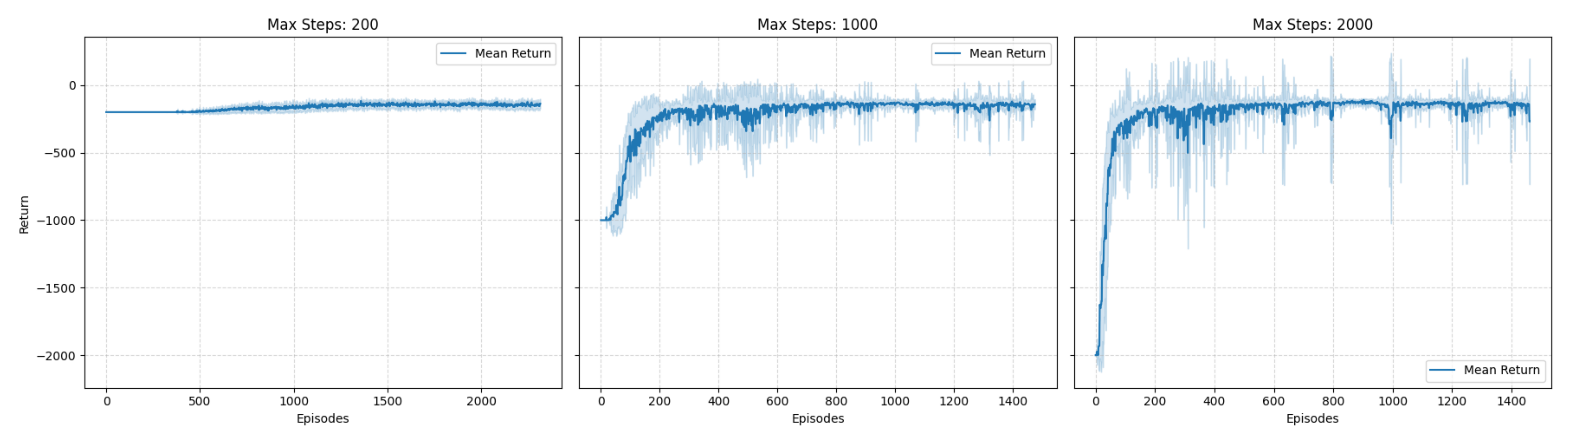

In [ ]:
#Changing the original code to account for varying truncation lenghts
def train(seed, truncation_length):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    env = gym.make("MountainCar-v0")
    env._max_episode_steps = truncation_length

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Move networks to GPU
    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)

    epsilon = EPS_START
    step_count = 0

    returns = []
    episode_return = 0

    state, _ = env.reset(seed=seed)

    while step_count < TOTAL_STEPS:
        # ε-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                q_vals = q_net(state_tensor)
                action = q_vals.argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, done)

        state = next_state
        episode_return += reward
        step_count += 1

        # ε decay
        epsilon = max(EPS_END, EPS_START - step_count / EPS_DECAY)

        # Training step
        if len(buffer) > BATCH_SIZE:
            s, a, r, s_next, d = buffer.sample(BATCH_SIZE)

            # Move batch to GPU
            s = s.to(device)
            a = a.to(device)
            r = r.to(device)
            s_next = s_next.to(device)
            d = d.to(device)

            # Current Q
            q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze()

            # Target Q
            with torch.no_grad():
                max_next_q = target_net(s_next).max(1)[0]
                target = r + GAMMA * max_next_q * (1 - d)

            loss = nn.MSELoss()(q_values, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Target network update (hard)
        if step_count % TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())

        # Episode reset
        if done:
            returns.append(episode_return)
            state, _ = env.reset()
            episode_return = 0

    env.close()
    return returns, q_net


#Storing all the answers as a nested list of 15 elements with each element being a list of 3 values
all_returns = []
models = []
max_episode_steps = [200,1000,2000]
for seed in range(15):
  per_length_return, per_length_model = [], []
  for run_len in max_episode_steps:
      print(f"Running seed {seed}: truncation length {run_len}")
      returns, model = train(seed, run_len)
      per_length_return.append(returns)
      per_length_model.append(model)
  all_returns.append(per_length_return)
  models.append(per_length_model)
  print(f"Finished seed {seed}")


num_lengths = len(max_episode_steps)
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax in enumerate(axes):
    # Extract the data for the current truncation length (i) across all 15 seeds
    data_for_length = [seed_data[i] for seed_data in all_returns]

    # Align lengths
    min_len = min(len(r) for r in data_for_length)
    trimmed = np.array([r[:min_len] for r in data_for_length])

    # Stats
    mean_vals = trimmed.mean(axis=0)
    std_vals = trimmed.std(axis=0)

    # Plotting on the specific subplot (ax)
    epochs = range(min_len)
    ax.plot(epochs, mean_vals, color='tab:blue', label="Mean Return")
    ax.fill_between(
        epochs,
        mean_vals - std_vals,
        mean_vals + std_vals,
        color='tab:blue',
        alpha=0.2
    )

    # Formatting each subplot
    ax.set_title(f"Max Steps: {max_episode_steps[i]}")
    ax.set_xlabel("Episodes")
    if i == 0:
        ax.set_ylabel("Return")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.savefig("dqn_truncation_lengths.png", dpi=300, bbox_inches="tight")
plt.show()

'''
The above code was run locally in desktops soo the output below wont show the entire process
I will load the image file generated from the above code manually
'''
img = mpimg.imread('dqn_truncation_lengths.png')
# Set figure size (width, height) in inches
plt.figure(figsize=(20, 14))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
with open("dqn_mountaincar.pkl", "wb") as f:
    pickle.dump(models[0].state_dict(), f)

# 4

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, action_dim)
        )

        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(np.array(a), dtype=torch.long),
            torch.tensor(np.array(r), dtype=torch.float32),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(np.array(done), dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

In [ ]:
REPLAY_FACTOR   = [1, 2, 4, 8]
TRUNCATION_LEN  = 2000
BUFFER_CAPACITY = 50000
BATCH_SIZE      = 64
GAMMA           = 0.99
LR              = 1e-3
EPSILON_START   = 1.0
EPSILON_END     = 0.05
EPSILON_DECAY   = 50000
TARGET_UPDATE   = 500
MAX_TIMESTEPS   = 200000
MIN_BUFFER_SIZE = 500
PRINT_EVERY     = 10

env = gym.make("MountainCar-v0", max_episode_steps=2000)
state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.n

for rep_fact in REPLAY_FACTOR:

    q_net = QNetwork(state_dim, action_dim)
    q_target = QNetwork(state_dim, action_dim)
    q_target.load_state_dict(q_net.state_dict())
    q_target.eval()
    optimizer = torch.optim.Adam(q_net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_CAPACITY)

    all_returns, episode_steps = [], []
    timestep, ep_return = 0, 0
    epsilon  = EPSILON_START
    state, _ = env.reset()

    print(f"Training started with ρ = {rep_fact}")

    while timestep < MAX_TIMESTEPS:

        epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * \
            np.exp(-timestep / EPSILON_DECAY)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_vals = q_net(torch.tensor(state, dtype=torch.float32))
                action = q_vals.argmax().item()

        next_state, reward, terminated, truncated , _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, float(done))
        state      = next_state
        ep_return += reward
        timestep  += 1

        if len(buffer) >= MIN_BUFFER_SIZE:
            for _ in range(rep_fact):
                s, a, r, s_next, d = buffer.sample(BATCH_SIZE)

                with torch.no_grad():
                    target = r + GAMMA * q_target(s_next).max(dim=1).values * (1 - d)

                q_val = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss  = F.mse_loss(q_val, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if timestep % TARGET_UPDATE == 0:
            q_target.load_state_dict(q_net.state_dict())

        if done:
            all_returns.append(ep_return)
            episode_steps.append(timestep)
            state, _ = env.reset()
            ep_return = 0

            if len(all_returns) % PRINT_EVERY == 0:
                mean_return = np.mean(all_returns[-50:])
                best_return = np.max(all_returns)
                print(
                    f"[ ρ = {rep_fact} ] "
                    f"Episode: {len(all_returns):>5} | "
                    f"ε: {epsilon:.3f} | "
                    f"Best: {best_return:>7.1f} | "
                    f"Mean (50): {mean_return:>7.1f}"
                )

    results = {
        "returns":       all_returns,
        "episode_steps": episode_steps,
        "replay_factor": rep_fact,
    }

    filename = f"dqn_rho{rep_fact}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(results, f)
    from google.colab import files
    files.download(filename)

    print(f"Saved results to {filename}")
    print(f"Episodes completed   : {len(all_returns)}")
    print(f"Mean return (last 50): {np.mean(all_returns[-50:]):.2f}\n")

In [ ]:
from scipy import stats

In [ ]:
REPLAY_FACTOR   = [1, 2, 4, 8]
TRUNCATION_LEN  = 2000
BUFFER_CAPACITY = 50000
BATCH_SIZE      = 64
GAMMA           = 0.99
LR              = 1e-3
EPSILON_START   = 1.0
EPSILON_END     = 0.05
EPSILON_DECAY   = 50000
TARGET_UPDATE   = 500
MAX_TIMESTEPS   = 200000
MIN_BUFFER_SIZE = 500
PRINT_EVERY     = 10
TARGET_REWARD   = -100


In [ ]:
def train(seed, rep_fact):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device("cpu")

    env = gym.make("MountainCar-v0", max_episode_steps=TRUNCATION_LEN)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net      = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LR)
    buffer    = ReplayBuffer(BUFFER_CAPACITY)

    epsilon        = EPSILON_START
    step_count     = 0
    returns        = []
    episode_return = 0

    state, _ = env.reset(seed=seed)

    print(f"Training ρ = {rep_fact} | Seed = {seed} | Device = {device}")

    while step_count < MAX_TIMESTEPS:

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action = q_net(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, float(terminated))

        state           = next_state
        episode_return += reward
        step_count     += 1

        epsilon = max(EPSILON_END, EPSILON_START - step_count / EPSILON_DECAY)

        if len(buffer) > MIN_BUFFER_SIZE:
            for _ in range(rep_fact):
                s, a, r, s_next, d = buffer.sample(BATCH_SIZE)
                s, a, r, s_next, d = (s.to(device), a.to(device),
                                      r.to(device), s_next.to(device),
                                      d.to(device))

                q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze()

                with torch.no_grad():
                    target = r + GAMMA * target_net(s_next).max(1)[0] * (1 - d)

                loss = nn.MSELoss()(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if step_count % TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())

        if done:
            returns.append(episode_return)

            if len(returns) % PRINT_EVERY == 0:
                print(
                    f"[ ρ = {rep_fact} | seed = {seed} ] "
                    f"Episode: {len(returns):>5} | "
                    f"ε: {epsilon:.3f} | "
                    f"Best: {max(returns):>8.1f} | "
                    f"Mean (50): {np.mean(returns[-50:]):>8.1f}"
                )

            state, _       = env.reset()
            episode_return = 0

    env.close()

    results  = {"returns": returns, "replay_factor": rep_fact, "seed": seed}
    filename = f"dqn_rho{rep_fact}_seed{seed}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(results, f)

    from google.colab import files
    files.download(filename)

    print(f"Saved here bro {filename} | Episodes: {len(returns)} | "
          f"Mean (last 50): {np.mean(returns[-50:]):.2f}\n")

    return returns




In [ ]:
REPLAY_FACTORS = [1, 2, 4, 8]
SEEDS          = list(range(15))

In [ ]:
# training
for rep_fact in REPLAY_FACTORS:
    for seed in SEEDS:
        train(seed, rep_fact)

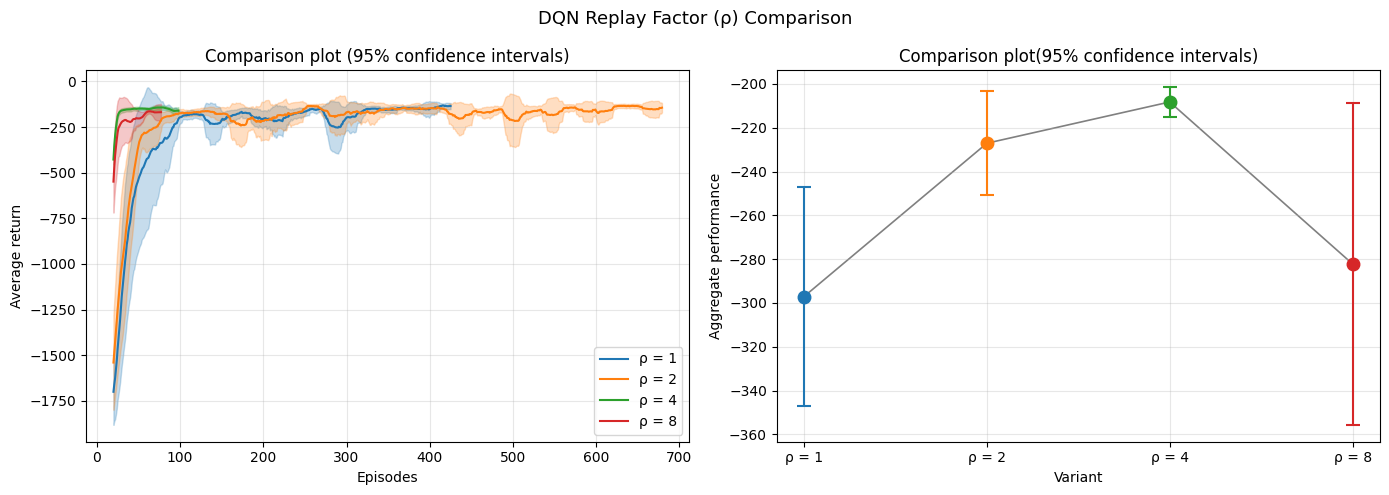

In [ ]:
COLORS         = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
SMOOTH_WINDOW  = 20
VARIANTS       = [f"ρ = {r}" for r in REPLAY_FACTORS]

def smooth(x, window):
    return np.convolve(x, np.ones(window) / window, mode='valid')

def load_and_align(rho, seeds):
    all_seed_returns = []
    for seed in seeds:
        with open(f"dqn_rho{rho}_seed{seed}.pkl", "rb") as f:
            data = pickle.load(f)
        all_seed_returns.append(np.array(data["returns"]))
    min_len = min(len(r) for r in all_seed_returns)
    return np.array([r[:min_len] for r in all_seed_returns])

def compute_ci(aligned, confidence=0.95):
    mean = aligned.mean(axis=0)
    se   = stats.sem(aligned, axis=0)
    h    = se * stats.t.ppf((1 + confidence) / 2, df=aligned.shape[0] - 1)
    return mean, mean - h, mean + h

all_data = {}
for rho in REPLAY_FACTORS:
    aligned = load_and_align(rho, SEEDS)
    smoothed = np.array([smooth(r, SMOOTH_WINDOW) for r in aligned])
    all_data[rho] = {
        "aligned":  aligned,
        "smoothed": smoothed,
    }


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3a kinda plot
for i, (rho, color) in enumerate(zip(REPLAY_FACTORS, COLORS)):
    smoothed = all_data[rho]["smoothed"]
    mean, lower, upper = compute_ci(smoothed)
    episodes = np.arange(SMOOTH_WINDOW, SMOOTH_WINDOW + len(mean))

    axes[0].plot(episodes, mean, label=f"ρ = {rho}", color=color, linewidth=1.5)
    axes[0].fill_between(episodes, lower, upper, alpha=0.25, color=color)

axes[0].set_title("Comparison plot (95% confidence intervals)")
axes[0].set_xlabel("Episodes")
axes[0].set_ylabel("Average return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 3b kinda plot
agg_means  = []
agg_lowers = []
agg_uppers = []

for rho in REPLAY_FACTORS:
    aligned = all_data[rho]["aligned"]

    per_seed_mean = aligned.mean(axis=1)

    mean  = per_seed_mean.mean()
    se    = stats.sem(per_seed_mean)
    h     = se * stats.t.ppf(0.975, df=len(SEEDS) - 1)

    agg_means.append(mean)
    agg_lowers.append(mean - h)
    agg_uppers.append(mean + h)

agg_means  = np.array(agg_means)
agg_lowers = np.array(agg_lowers)
agg_uppers = np.array(agg_uppers)
yerr_low   = agg_means - agg_lowers
yerr_high  = agg_uppers - agg_means

x_pos = np.arange(len(REPLAY_FACTORS))


axes[1].plot(x_pos, agg_means, color='gray', linewidth=1.2, zorder=1)

for i, (rho, color) in enumerate(zip(REPLAY_FACTORS, COLORS)):
    axes[1].errorbar(
        x_pos[i], agg_means[i],
        yerr=[[yerr_low[i]], [yerr_high[i]]],
        fmt='o', color=color, markersize=9,
        capsize=5, capthick=1.5, elinewidth=1.5,
        zorder=2
    )

axes[1].set_title("Comparison plot(95% confidence intervals)")
axes[1].set_xlabel("Variant")
axes[1].set_ylabel("Aggregate performance")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"ρ = {r}" for r in REPLAY_FACTORS])
axes[1].grid(True, alpha=0.3)

plt.suptitle("DQN Replay Factor (ρ) Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("dqn_rho_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


#4b

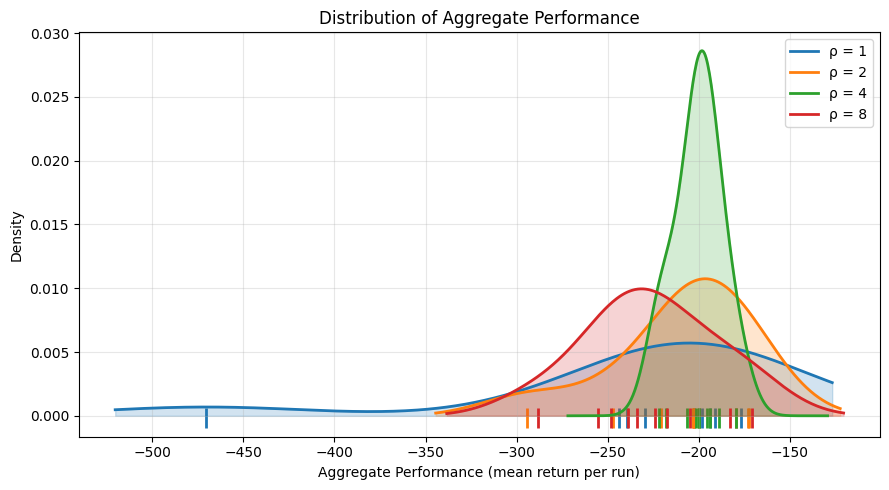

In [ ]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5))

for rho, color in zip(REPLAY_FACTOR, COLORS):
    # one aggregate value per seed = mean return across all episodes
    per_seed_agg = []
    for seed in SEEDS:
        with open(f"dqn_rho{rho}_seed{seed}.pkl", "rb") as f:
            data = pickle.load(f)
        per_seed_agg.append(np.mean(data["returns"]))  # scalar per seed

    per_seed_agg = np.array(per_seed_agg)

    # KDE
    kde    = gaussian_kde(per_seed_agg, bw_method='silverman')
    x_vals = np.linspace(per_seed_agg.min() - 50, per_seed_agg.max() + 50, 300)
    y_vals = kde(x_vals)

    ax.plot(x_vals, y_vals, label=f"ρ = {rho}", color=color, linewidth=2)
    ax.fill_between(x_vals, y_vals, alpha=0.2, color=color)

    # scatter rug at bottom to show actual samples
    ax.scatter(per_seed_agg, np.zeros_like(per_seed_agg) - 0.0002,
               color=color, marker='|', s=200, linewidths=2)

ax.set_title("Distribution of Aggregate Performance")
ax.set_xlabel("Aggregate Performance (mean return per run)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dqn_rho_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 4C

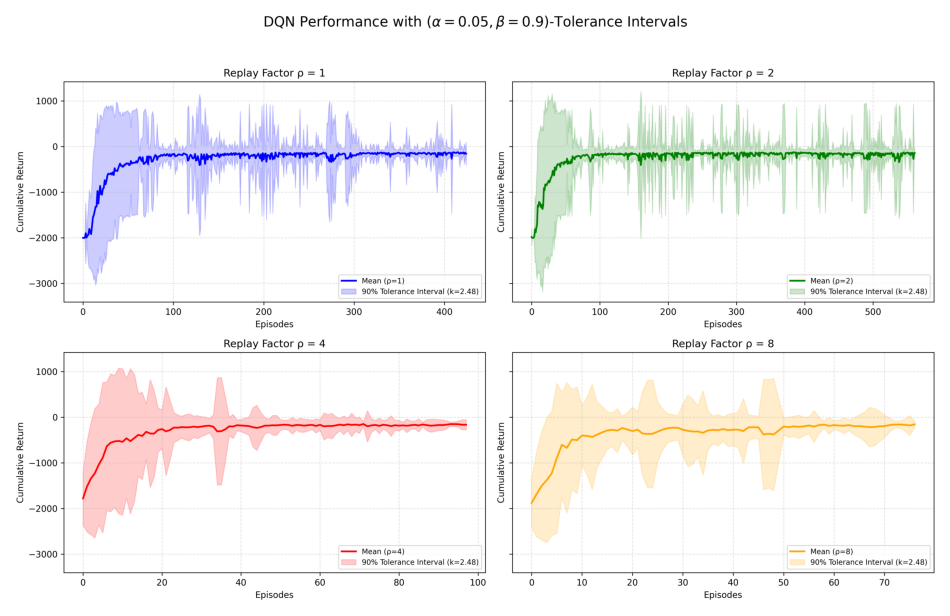

In [ ]:
alpha = 0.05 # 95% Confidence
beta = 0.90  # 90% Population Coverage
rho_values = [1, 2, 4, 8]
seeds = range(15) # Your current available seeds (0-14)
all_runs = []

for rho in rho_values:
        per_rho_runs = []
        for seed in seeds:
            filename = os.path.join("picklefiles", f"dqn_rho{rho}_seed{seed}.pkl")

            # Check if file exists before trying to open it
            if os.path.exists(filename):
                with open(filename, "rb") as f:
                    content = pickle.load(f)
                    per_rho_runs.append(content['returns'])
            else:
                print(f"Warning: {filename} not found.")

        all_runs.append(per_rho_runs)

# --- Plotting the results with confidence intervals ---
# --- Statistical Parameters ---
alpha = 0.05  # 95% Confidence level
beta = 0.90   # 90% Population coverage
rho_values = [1, 2, 4, 8]
colors = {1: 'blue', 2: 'green', 4: 'red', 8: 'orange'}

# Setup 2x2 Subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for i, rho in enumerate(rho_values):
    per_rho_runs = all_runs[i]
    ax = axes[i]

    if not per_rho_runs:
        ax.set_title(f"Replay Factor ρ={rho} (No Data Found)")
        continue

    # 1. Standardize length (MountainCar-v0 with 2000 step truncation)
    min_len = min(len(r) for r in per_rho_runs)
    runs_array = np.array([r[:min_len] for r in per_rho_runs])

    n = runs_array.shape[0]  # Number of seeds currently processed (n=15)
    dof = n - 1

    # 2. Calculate the k-factor for (alpha=0.05, beta=0.9)
    # For n=15, dof=14, we can use the normal distribution for z_beta and chi-squared distribution for chi2_alpha
    z_beta = stats.norm.ppf((1 + beta) / 2)
    chi2_alpha = stats.chi2.ppf(alpha, dof)
    k_factor = z_beta * np.sqrt(dof * (1 + 1/n) / chi2_alpha)

    # 3. Calculate Mean and Variability for the Tolerance Interval
    mean_perf = np.mean(runs_array, axis=0)
    std_perf = np.std(runs_array, axis=0, ddof=1)

    non_zero_stds = std_perf[std_perf > 0]
    # Calculate min only if there are non-zero values to avoid a ValueError
    min_val = np.min(non_zero_stds) if non_zero_stds.size > 0 else 0.0
    print("(Max : Min) standard deviation across episodes for ρ={}: ({:.2f}, {:.2f})".format(rho, np.max(std_perf), min_val))

    # 4. Determine the Tolerance Interval margin
    margin = k_factor * std_perf
    episodes = np.arange(min_len)

    # Plotting each subplot
    ax.plot(episodes, mean_perf, label=f'Mean (ρ={rho})', color=colors[rho], lw=2)
    ax.fill_between(episodes,
                     mean_perf - margin,
                     mean_perf + margin,
                     color=colors[rho], alpha=0.2,
                     label=f'90% Tolerance Interval (k={k_factor:.2f})')

    ax.set_title(f"Replay Factor ρ = {rho}")
    ax.set_xlabel("Episodes")
    ax.set_ylabel("Cumulative Return")
    ax.legend(loc='lower right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(r"DQN Performance with $(\alpha=0.05, \beta=0.9)$-Tolerance Intervals", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("dqn_tolerance_intervals_plot.png", dpi=300, bbox_inches='tight')
plt.show()

#The above code was used to generate the png file shown below.
#Loading the png file manually as it was done in a local desktop.
img = mpimg.imread('dqn_tolerance_intervals_plot.png')
# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off') # Optional: hides the X and Y axes
plt.show()

#4d

In [ ]:
BATCH_SIZES     = [16, 32, 64, 128, 256]
TARGET_UPDATES  = [100, 250, 500, 1000, 2000]
RHO             = [1, 4]
SEEDS           = list(range(15))

In [ ]:
# Train function
def train_sensitivity(seed, rep_fact, batch_size, target_update):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device("cpu")
    env    = gym.make("MountainCar-v0", max_episode_steps=TRUNCATION_LEN)

    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net      = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LR)
    buffer    = ReplayBuffer(BUFFER_CAPACITY)

    epsilon        = EPSILON_START
    step_count     = 0
    returns        = []
    episode_return = 0

    state, _ = env.reset(seed=seed)

    while step_count < MAX_TIMESTEPS:

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                st = torch.from_numpy(state).float().unsqueeze(0).to(device)
                action = q_net(st).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, float(terminated))
        state           = next_state
        episode_return += reward
        step_count     += 1

        epsilon = max(EPSILON_END, EPSILON_START - step_count / EPSILON_DECAY)

        if len(buffer) > MIN_BUFFER_SIZE:
            for _ in range(rep_fact):
                s, a, r, s_next, d = buffer.sample(batch_size)

                s      = torch.from_numpy(np.array(s)).float().to(device)
                a      = torch.from_numpy(np.array(a)).long().to(device)
                r      = torch.from_numpy(np.array(r)).float().to(device)
                s_next = torch.from_numpy(np.array(s_next)).float().to(device)
                d      = torch.from_numpy(np.array(d)).float().to(device)

                q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    target = r + GAMMA * target_net(s_next).max(1)[0] * (1 - d)

                loss = nn.MSELoss()(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if step_count % target_update == 0:
            target_net.load_state_dict(q_net.state_dict())

        if done:
            returns.append(episode_return)
            if len(returns) % PRINT_EVERY == 0:
                print(
                    f"[ ρ = {rep_fact} | seed = {seed} ] "
                    f"Episode: {len(returns):>5} | "
                    f"ε: {epsilon:.3f} | "
                    f"Best: {max(returns):>8.1f} | "
                    f"Mean (50): {np.mean(returns[-50:]):>8.1f}"
                )

            state, _       = env.reset()
            episode_return = 0



    env.close()

    results  = {
        "returns":       returns,
        "replay_factor": rep_fact,
        "batch_size":    batch_size,
        "target_update": target_update,
        "seed":          seed,
    }

    # Define the save path within your Google Drive
    save_dir = "/content/drive/MyDrive/Colab_DQN_Results"
    os.makedirs(save_dir, exist_ok=True) # Create directory if it doesn't exist
    filename = f"sens_rho{rep_fact}_bs{batch_size}_tu{target_update}_seed{seed}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(results, f)

    from google.colab import files
    files.download(filename)

    return returns

In [ ]:
print("-- Batch Size Sensitivity --")
for rho in RHO:
    for bs in BATCH_SIZES:
        for seed in SEEDS:
            print(f"ρ={rho} | batch_size={bs} | seed={seed}")
            train_sensitivity(seed, rho, bs, TARGET_UPDATE)

In [ ]:
print("-- Target Update Sensitivity --")
for rho in RHO:
    for tu in TARGET_UPDATES:
        for seed in SEEDS:
            print(f"ρ={rho} | target_update={tu} | seed={seed}")
            train_sensitivity(seed, rho, BATCH_SIZE, tu)

## Q5 - BONUS

In [ ]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta=0.4, beta_increment=0.001):
        self.buffer = deque(maxlen=capacity)
        self.priorities = deque(maxlen=capacity)
        self.alpha = alpha  # Determines how much prioritization is used (0 = uniform)
        self.beta = beta    # To compensate for bias via importance sampling
        self.beta_increment = beta_increment
        self.epsilon = 1e-6 # Small constant to ensure non-zero probability

    def push(self, s, a, r, s_next, done):
        # New transitions start with maximum priority to ensure they are sampled at least once
        max_prio = max(self.priorities) if self.buffer else 1.0
        self.buffer.append((s, a, r, s_next, done))
        self.priorities.append(max_prio)

    def sample(self, batch_size):
        # 1. Calculate sampling probabilities: P(i) = p_i^alpha / sum(p_j^alpha)
        prios = np.array(self.priorities)
        probs = prios ** self.alpha
        probs /= probs.sum()

        # 2. Sample indices based on probabilities
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        # 3. Compute Importance Sampling (IS) weights: w_i = (1/N * 1/P(i))^beta
        self.beta = min(1.0, self.beta + self.beta_increment)
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-self.beta)
        weights /= weights.max()  # Normalize for stability

        s, a, r, s_next, done = zip(*samples)

        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(np.array(a), dtype=torch.long),
            torch.tensor(np.array(r), dtype=torch.float32),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(np.array(done), dtype=torch.float32),
            torch.tensor(indices, dtype=torch.long),
            torch.tensor(weights, dtype=torch.float32)
        )

    def update_priorities(self, indices, errors):
        # Errors are typically the absolute TD error: |reward + gamma * maxQ(s') - Q(s)|
        for idx, error in zip(indices, errors):
            self.priorities[idx] = abs(error) + self.epsilon

    def __len__(self):
        return len(self.buffer)

In [ ]:
def train(seed, rep_fact): # Added rep_fact (rho) as an argument
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = gym.make("MountainCar-v0")
    env._max_episode_steps = MAX_EPISODE_STEPS # Ensure this is 2000 as per PDF [cite: 32]

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LR)

    # Initialize PER Buffer
    buffer = PrioritizedReplayBuffer(BUFFER_SIZE)

    epsilon = EPS_START
    step_count = 0
    returns = []
    episode_return = 0

    state, _ = env.reset(seed=seed)

    while step_count < TOTAL_STEPS:
        # ε-greedy action selection
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action = q_net(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # New experiences are pushed with max priority inside the class
        buffer.push(state, action, reward, next_state, done)

        state = next_state
        episode_return += reward
        step_count += 1
        epsilon = max(EPS_END, EPS_START - step_count / EPS_DECAY)

        # --- START OF REPLAY FACTOR (rho) LOOP ---
        # Implementation of Question 4: Update 'rep_fact' times per timestep
        if len(buffer) > BATCH_SIZE:
            for _ in range(rep_fact):
                # 1. Sample with weights and indices [cite: 142, 144]
                s, a, r, sn, d, indices, weights = buffer.sample(BATCH_SIZE)

                s, a, r, sn, d = s.to(device), a.to(device), r.to(device), sn.to(device), d.to(device)
                weights = weights.to(device)

                # 2. Compute Current Q
                q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze()

                # 3. Compute Target Q
                with torch.no_grad():
                    max_next_q = target_net(sn).max(1)[0]
                    target = r + GAMMA * max_next_q * (1 - d)

                # 4. Calculate TD Error for priority update
                # We use .abs() because PER prioritizes based on absolute error
                td_errors = torch.abs(q_values - target).detach().cpu().numpy()
                buffer.update_priorities(indices.numpy(), td_errors)

                # 5. Apply Importance Sampling weights to the loss
                # This corrects the bias of non-uniform sampling
                elementwise_loss = F.mse_loss(q_values, target, reduction='none')
                loss = (elementwise_loss * weights).mean()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        # --- END OF REPLAY FACTOR LOOP ---

        if step_count % TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())

        if done:
            returns.append(episode_return)
            if len(returns) % 10 == 0:
                print(
                    f"[ ρ = {rep_fact} | seed = {seed} ] "
                    f"Episode: {len(returns):>5} | "
                    f"ε: {epsilon:.3f} | "
                    f"Best: {max(returns):>8.1f} | "
                    f"Mean (50): {np.mean(returns[-50:]):>8.1f}"
                )
            state, _ = env.reset()
            episode_return = 0

    env.close()

    results  = {"returns": returns, "replay_factor": rep_fact, "seed": seed}
    filename = f"dqn_rho{rep_fact}_seed{seed}_PERbuffer.pkl"
    with open(filename, "wb") as f:
        pickle.dump(results, f)

    from google.colab import files
    files.download(filename)

    print(f"Saved here bro {filename} | Episodes: {len(returns)} | "
          f"Mean (last 50): {np.mean(returns[-50:]):.2f}\n")
    return returns

In [ ]:
all_returns = []
for seed in range(4):
    print(f"Running seed {seed}")
    returns = train(seed, 1)
    all_returns.append(returns)

[0. 0. 0. ... 0. 0. 0.]


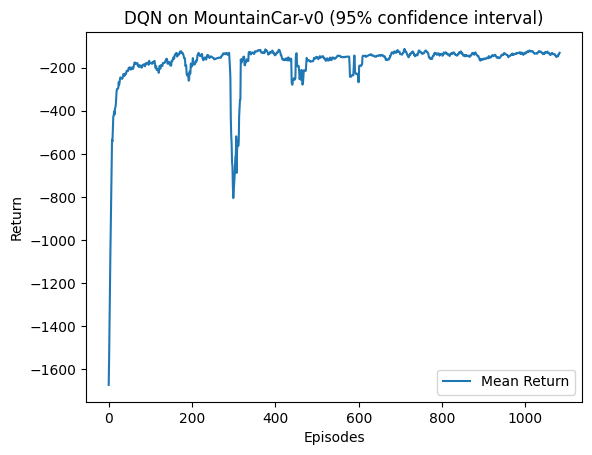

In [ ]:
returns_trimmed = np.array(all_returns)
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

mean_returns = moving_avg(returns_trimmed.mean(axis=0))

print(std_returns)
x = np.arange(len(mean_returns))
ci = 1.96 * std_returns / np.sqrt(15)
plt.figure()
plt.plot(x,mean_returns, label="Mean Return")
plt.fill_between(
    x,
    mean_returns - ci,
    mean_returns + ci,
    alpha=0.3
)
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("DQN on MountainCar-v0 (95% confidence interval)")
plt.legend()
plt.show()